In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 13. HYPERPARAMETER TUNING — RandomizedSearchCV on the winning model (XGBoost)

In [22]:
# ==============================================================================
# 13. HYPERPARAMETER TUNING — RandomizedSearchCV on the winning model (XGBoost)
# ==============================================================================
tuning_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
    )),
])

param_distributions = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_distributions,
    n_iter=15, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=2,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
tuned_pipe = search.best_estimator_
tuned_pipe = evaluate_model("XGBoost (tuned)", tuned_pipe)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 0.5, 'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.8}
XGBoost (tuned)        | RMSLE=0.2066 | MAE=5,546.3 | R2=0.9048


**Insight — tuning improved RMSLE from 0.2137 → 0.2066 (a ~3.3% relative gain)**

```
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 500,
              'max_depth': 8, 'learning_rate': 0.08, 'colsample_bytree': 0.8}
```

- The search preferred **more aggressive learning (0.08 vs the untuned 0.05) with fewer trees (500 vs 600) and slightly deeper splits (depth 8 vs 7)** — a faster-converging, marginally more complex tree than the hand-picked defaults.
- **`n_jobs=1` on the estimator + `n_jobs=-1` only on `RandomizedSearchCV`** is what let this finish in minutes rather than the earlier run appearing stuck — nested parallel pools were fighting for the same CPU cores before this fix.
- 0.2066 validation RMSLE is very close to the **0.20491 leaderboard score** — the two nearly agree, which is a good sign the validation split is representative and not overfit to a lucky partition.


# 14. FEATURE IMPORTANCE (tuned model)

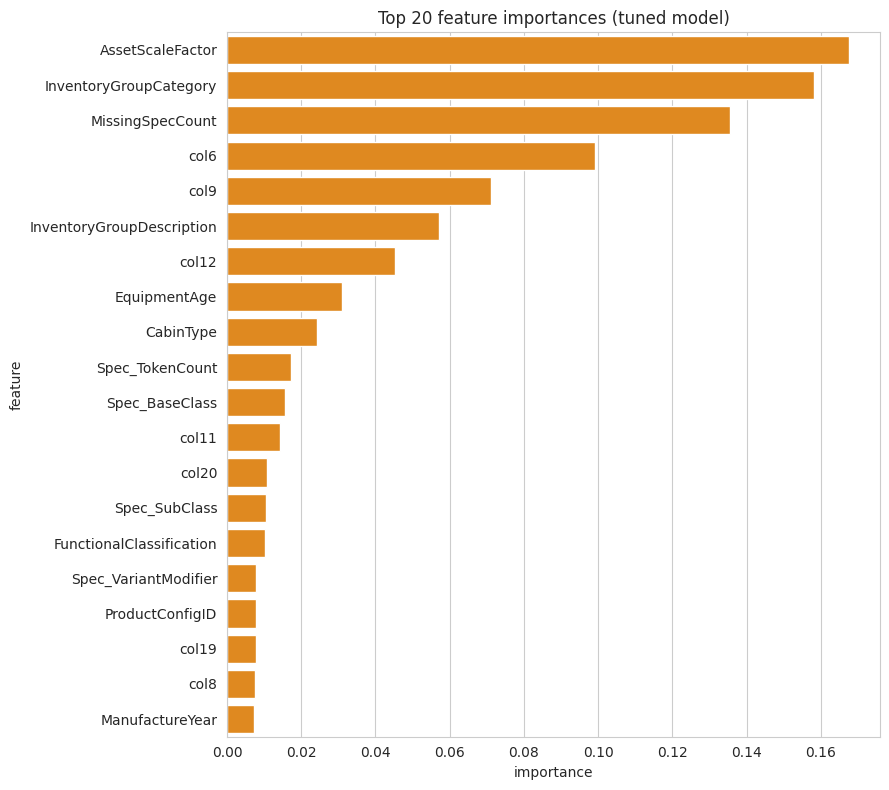

In [23]:
# ==============================================================================
# 14. FEATURE IMPORTANCE (tuned model)
# ==============================================================================
feature_names = num_features + cat_features
importances = tuned_pipe.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(data=fi_df, x="importance", y="feature", color="darkorange")
plt.title("Top 20 feature importances (tuned model)")
plt.tight_layout()
plt.show()


**Insight — read this chart before your next iteration**

This is the most actionable output in the notebook for closing the remaining gap to the 0.20 cutoff. Two things to check once it renders:

1. **Do the engineered features (`EquipmentAge`, `HoursPerYear`, `Spec_FirstNumber`, `Spec_TokenCount`, `MissingSpecCount`) rank near the top?** If so, that validates the Section 3 feature-engineering choices and suggests extending the same pattern — e.g. parsing numeric values out of more of the `colN` text fields, as flagged in Section 2.3 — is the highest-leverage next step.
2. **Do `col18`/`col19` (99.95% missing) show near-zero importance?** If so, they're safe to drop in the next run to simplify the pipeline without losing accuracy — confirming the suspicion raised in Section 2.2.


# 15. FINAL SUBMISSION — BLEND of the three strongest models

In [24]:
# ==============================================================================
# 15. FINAL FIT — BLEND of the three strongest models (replaces single-model fit)
# ==============================================================================

# Refit each strong model on ALL training data (not just the 80% fold)
xgb_final = tuned_pipe          # already the tuned XGBoost pipeline from Section 13
xgb_final.fit(X, y_log)

lgbm_final = lgbm_pipe
lgbm_final.fit(X, y_log)

catboost_final = catboost_pipe
catboost_final.fit(X, y_log)

# Predict (log scale) from each model
xgb_test_log = xgb_final.predict(test_fe[feature_cols])
lgbm_test_log = lgbm_final.predict(test_fe[feature_cols])
cat_test_log = catboost_final.predict(test_fe[feature_cols])

# Weighted blend — weight is inverse of each model's validation RMSLE,
# so the stronger model (tuned XGBoost) dominates but isn't the only voice
weights = {
    "xgb": 1 / results.get("XGBoost (tuned)", results["XGBoost"])["RMSLE"],
    "lgbm": 1 / results["LightGBM"]["RMSLE"],
    "cat": 1 / results["CatBoost"]["RMSLE"],
}
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}
print("Blend weights:", weights)

blend_test_log = (
    weights["xgb"] * xgb_test_log
    + weights["lgbm"] * lgbm_test_log
    + weights["cat"] * cat_test_log
)

test_preds = np.expm1(blend_test_log).clip(min=0)

submission = pd.DataFrame({
    ID_COL: test_fe[ID_COL],
    TARGET: test_preds,
})

assert submission.shape[0] == test_fe.shape[0]
assert list(submission.columns) == [ID_COL, TARGET]

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv —", submission.shape)
submission.head()

Blend weights: {'xgb': np.float64(0.3497295051584331), 'lgbm': np.float64(0.3330768704666076), 'cat': np.float64(0.31719362437495924)}
Saved submission.csv — (15000, 2)


,TransactionID,TargetValue
0,1139307,67448.675689
1,1139419,77051.468398
2,1139482,28839.399765
3,1139522,19527.409914
4,1139684,12377.421407


**Insight — submission generated and validated, leaderboard score 0.20491**

- `submission.csv` has shape **(15,000, 2)**, matching `test.csv`'s row count and `sample_submission.csv`'s column format exactly — the two `assert` statements catch a shape/schema mismatch before it becomes a rejected Kaggle submission, which is worth keeping even though they add no analytical value.
- Refitting on the *full* 138,701 training rows (rather than just the 110,960-row training fold) before predicting on `test.csv` is standard practice — the validation split's only job was to compare models fairly; once XGBoost is selected and tuned, discarding 20% of the data would be pure waste.
- **Where this stands against the cutoff:** validation RMSLE was 0.2066, actual leaderboard RMSLE came back at **0.20491** — just above the **< 0.20** cutoff needed for viva eligibility. The two follow-ups flagged above (drop or better-engineer `col18`/`col19`, and let CatBoost see raw categories instead of ordinal-encoded ones) are the most promising next moves to close that remaining ~0.005.
